In [10]:
import polars as pl

assay_type = pl.read_parquet(
    "/tgen_labs/altin/alphafold3/workspace/tcrtrifold-experiments/data/iedb_meta/assay_type.parquet"
)

iedb_II = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.conf_af3.parquet"
)

iedb_II_n = iedb_II.filter(~pl.col("cognate")).explode("receptor_id")

iedb_II_at = (
    iedb_II.filter(pl.col("cognate"))
    .explode("receptor_id")
    .join(assay_type, on="receptor_id")
)

iedb_II_at = iedb_II_at.with_columns(
    (31 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")
)

In [11]:
import matplotlib.pyplot as plt


def plot_violins(label, values):
    n = len(label)
    fig, ax = plt.subplots(figsize=(max(6, 0.8 * n), 4))

    vp = ax.violinplot(
        values,
        positions=range(1, n + 1),
        widths=0.8,
        showmedians=True,
        showextrema=False,
    )

    for body in vp["bodies"]:
        body.set_alpha(0.7)

    ax.set_xticks(range(1, n + 1))
    ax.set_xticklabels(label, rotation=45, ha="right")
    ax.set_xlim(0.5, n + 0.5)
    ax.set_ylabel("Value")
    plt.tight_layout()
    return fig, ax

## By antigen:study


(<Figure size 1120x400 with 1 Axes>, <Axes: ylabel='Value'>)

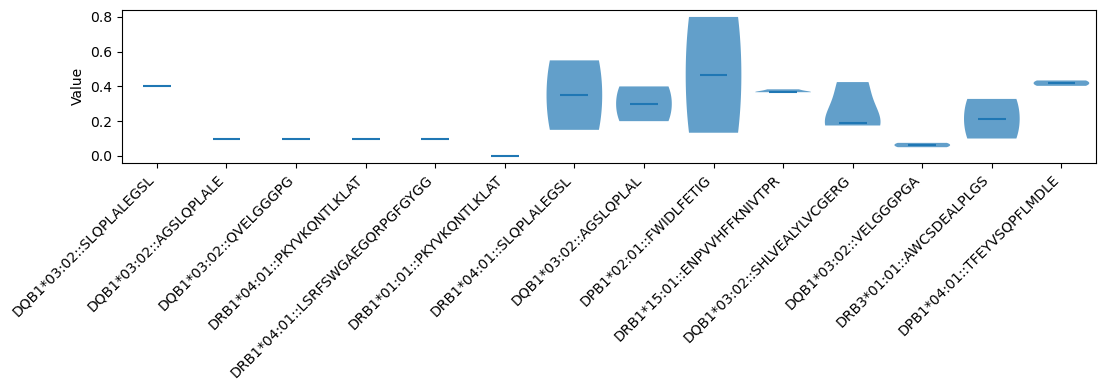

In [22]:
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS
from tcrtrifold.eval_utils import antigen_raw_score_auc
from sklearn import metrics

featname = "mean_p_tcr_pae"

antigen_count = (
    iedb_II.filter(pl.col("cognate"))
    .group_by(FORMAT_ANTIGEN_COLS)
    .len(name="n_tcr")
    .select(FORMAT_ANTIGEN_COLS + ["n_tcr"])
)
at_p = (
    iedb_II.filter(pl.col("cognate"))
    .join(antigen_count, on=FORMAT_ANTIGEN_COLS)
    .sort(by="n_tcr")
    .select(pl.exclude("n_tcr"))
    .partition_by(FORMAT_ANTIGEN_COLS, maintain_order=True)
)


auc_ls = []
study_id = []
lab = []

for p in at_p:

    partition_auc = []
    partition_study_id = []

    negatives = (
        iedb_II.filter(~pl.col("cognate"))
        .join(p.select(FORMAT_ANTIGEN_COLS)[0], on=FORMAT_ANTIGEN_COLS)
        .explode("references")
    )

    p_expl = p.explode("references")

    sub_p_by_ref = p_expl.partition_by("references", maintain_order=True)

    if len(sub_p_by_ref) < 2:
        continue

    lab.append(p[0].select("mhc_2_name").item() + "::" + p[0].select("peptide").item())

    for sub_p in sub_p_by_ref:
        focal_triad = pl.concat([sub_p, negatives])

        cog_arr = focal_triad.select("cognate").to_series().to_numpy()
        feat_arr = focal_triad.select(featname).to_series().to_numpy()

        auc = metrics.roc_auc_score(cog_arr, feat_arr)

        partition_auc.append(auc)
        partition_study_id.append(sub_p.select("references")[0].item())

    auc_ls.append(partition_auc)
    study_id.append(partition_study_id)

plot_violins(lab, auc_ls)